In [4]:
from google.colab import drive
import zipfile
import os


drive.mount('/content/drive')


print("Décompression en cours... Patiente un peu...")

with zipfile.ZipFile("/content/drive/MyDrive/beton.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Les images sont chargées dans Colab.")

Mounted at /content/drive
Décompression en cours... Patiente un peu...
Les images sont chargées dans Colab.


In [5]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
import os
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50

In [6]:
# On définit la taille des images
BATCH_SIZE = 32
IMG_HEIGHT = 227
IMG_WIDTH = 227
DATA_DIR = "/content/dataset"

print("--- Chargement des données ---")

# Création du jeu d'entraînement (On garde 80% des images pour apprendre)
train_ds = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,     # On sépare 20% pour tester
  subset="training",        # Ici on prend les 80% d'entraînement
  seed=123,                 # Grain aléatoire pour que le mélange soit toujours le même
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE)

#  Création du jeu de validation
val_ds = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="validation",      # Ici on prend les 20% de validation
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE)

# Affichage des classes trouvées
class_names = train_ds.class_names
print(f"\nLes classes trouvées sont : {class_names}")

#  Optimisation de la mémoire Cache pour aller plus vite
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

--- Chargement des données ---
Found 40000 files belonging to 2 classes.
Using 32000 files for training.
Found 40000 files belonging to 2 classes.
Using 8000 files for validation.

Les classes trouvées sont : ['Negative', 'Positive']


Construction et Entraînement du Modéle texte en gras

In [7]:
#  CONFIGURATION ---
BATCH_SIZE = 32
IMG_HEIGHT = 227
IMG_WIDTH = 227
DATA_DIR = "/content/dataset"


if not os.path.exists(DATA_DIR):
    print("ATTENTION : Le dossier dataset n'est pas trouvé. Veuillez relancer l'étape de décompression (zipfile).")
else:
    print("Dossier trouvé, on continue !")

    #  CHARGEMENT DES DONNÉES
    train_ds = tf.keras.utils.image_dataset_from_directory(
      DATA_DIR,
      validation_split=0.2,
      subset="training",
      seed=123,
      image_size=(IMG_HEIGHT, IMG_WIDTH),
      batch_size=BATCH_SIZE)

    val_ds = tf.keras.utils.image_dataset_from_directory(
      DATA_DIR,
      validation_split=0.2,
      subset="validation",
      seed=123,
      image_size=(IMG_HEIGHT, IMG_WIDTH),
      batch_size=BATCH_SIZE)


    train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    #  CRÉATION DU MODÈLE
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(227, 227, 3)),

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    #  ENTRAÎNEMENT
    print("Lancement de l'entraînement (version mémoire légère)...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30
    )

Dossier trouvé, on continue !
Found 40000 files belonging to 2 classes.
Using 32000 files for training.
Found 40000 files belonging to 2 classes.
Using 8000 files for validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Lancement de l'entraînement (version mémoire légère)...
Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 55ms/step - accuracy: 0.9031 - loss: 0.2201 - val_accuracy: 0.9912 - val_loss: 0.0223
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 56ms/step - accuracy: 0.9887 - loss: 0.0353 - val_accuracy: 0.9758 - val_loss: 0.0894
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 54s 54ms/step - accuracy: 0.9901 - loss: 0.0317 - val_accuracy: 0.9910 - val_loss: 0.0266
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 54s 54ms/step - accuracy: 0.9931 - loss: 0.0204 - val_accuracy: 0.9924 - val_loss: 0.0237
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.9949 - loss: 0.0169 - val_accuracy: 0.9942 - val_loss: 0.0200
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9958 - loss: 0.0146 - val_accuracy: 0.9936 - val_loss: 0.0218
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.9949 - loss: 0.0168 - val_accuracy: 0.9931 - val_loss: 0.0256
Epoch 8/30
1000/1000

 Modèle sauvegardé sous 'modele_beton_final_2.keras'


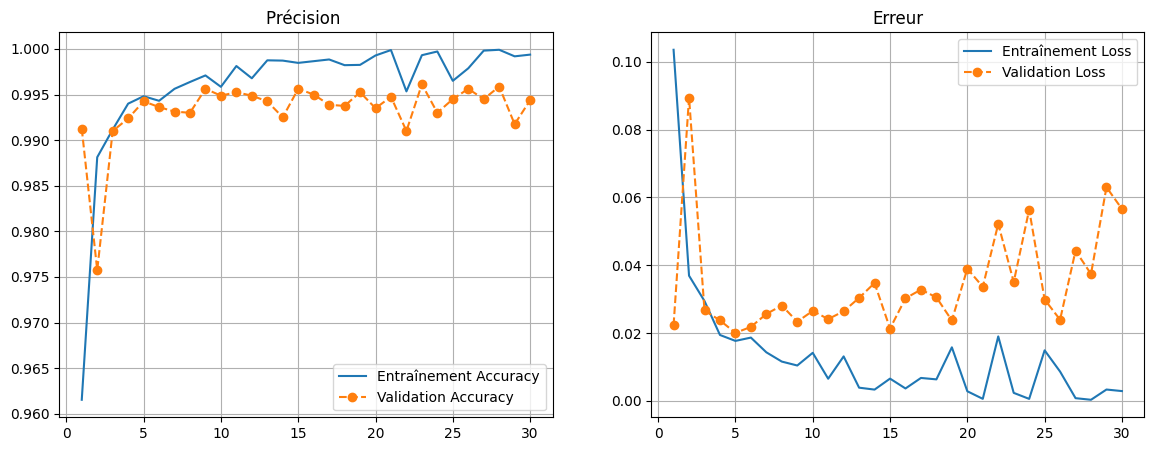

 Précision finale sur les données de test : 99.44%


In [8]:




#  Sauvegarde du modèle
model.save('modele_beton_final.keras')
print(" Modèle sauvegardé sous 'modele_beton_final_2.keras'")

#  Récupération des données de l'historique
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Création des Graphiques pour le rapport
plt.figure(figsize=(14, 5))

# Courbe de Précision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--', marker='o')
plt.legend(loc='lower right')
plt.title('Précision ')
plt.grid(True)

# Courbe de Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--', marker='o')
plt.legend(loc='upper right')
plt.title('Erreur')
plt.grid(True)

plt.show()

#  Affichage du résultat final
print(f" Précision finale sur les données de test : {val_acc[-1]*100:.2f}%")

In [9]:


# 1. Chargement du "Cerveau pré-entraîné" (ResNet50)
base_model = ResNet50(input_shape=(227, 227, 3),
                      include_top=False,
                      weights='imagenet')

base_model.trainable = False

#  Construction de la nouvelle tête
model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Résumé de l'image
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Technique pour éviter le sur-apprentissage (on désactive 20% des neurones au hasard)
    layers.Dense(1, activation='sigmoid')
])

#  Compilation
model_resnet.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
# Lancement de l'entraînement ResNet50
print(" Démarrage de l'entraînement ResNet50")

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Sauvegarde immédiate du modèle ResNet
model_resnet.save('modele_resnet_final.keras')
print("✅ Modèle ResNet sauvegardé !")

 Démarrage de l'entraînement ResNet50
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 129s 115ms/step - accuracy: 0.9640 - loss: 0.1079 - val_accuracy: 0.9976 - val_loss: 0.0087
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 130s 111ms/step - accuracy: 0.9982 - loss: 0.0078 - val_accuracy: 0.9979 - val_loss: 0.0071
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - accuracy: 0.9984 - loss: 0.0060 - val_accuracy: 0.9979 - val_loss: 0.0070
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - accuracy: 0.9987 - loss: 0.0048 - val_accuracy: 0.9980 - val_loss: 0.0062
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 142s 111ms/step - accuracy: 0.9990 - loss: 0.0042 - val_accuracy: 0.9979 - val_loss: 0.0059
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - accuracy: 0.9988 - loss: 0.0036 - val_accuracy: 0.9977 - val_loss: 0.0064
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 111ms/step - accuracy: 0.9991 - loss: 0.0034 - val_accuracy: 0.9983 - val_loss: 0.0055
Epoch 8/10
1000/1000 ━━━

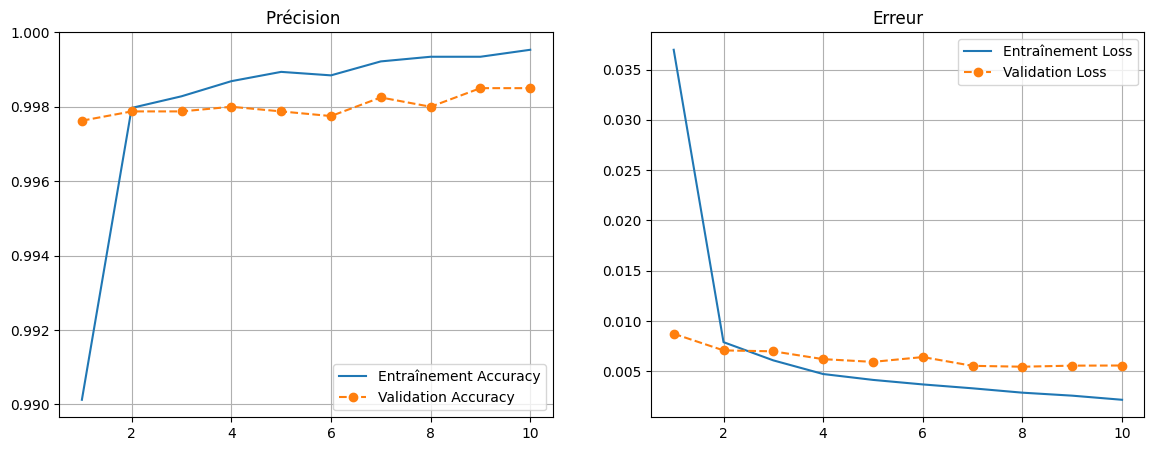

 Précision finale sur les données de test : 99.85%


In [11]:

acc = history_resnet.history['accuracy']
val_acc = history_resnet.history['val_accuracy']
loss = history_resnet.history['loss']
val_loss = history_resnet.history['val_loss']
epochs_range = range(1, len(acc) + 1)

#  Création des Graphiques pour le rapport
plt.figure(figsize=(14, 5))

# Courbe de Précision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--', marker='o')
plt.legend(loc='lower right')
plt.title('Précision ')
plt.grid(True)

# Courbe de Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--', marker='o')
plt.legend(loc='upper right')
plt.title('Erreur')
plt.grid(True)

plt.show()

#  Affichage du résultat final
print(f" Précision finale sur les données de test : {val_acc[-1]*100:.2f}%")

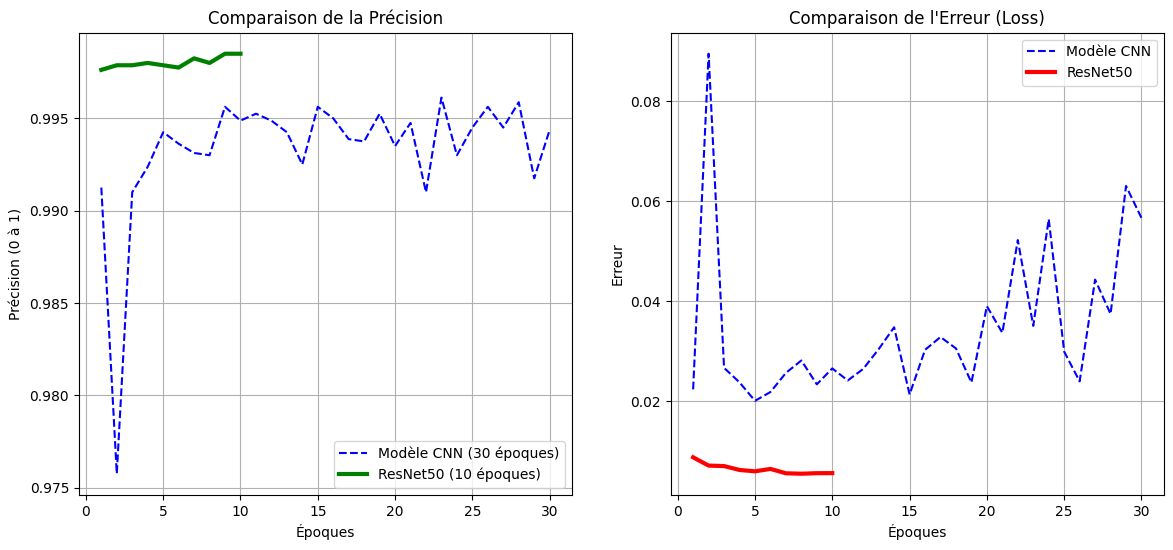

🔹 Score final Modèle CNN (après 30 époques) : 99.44%
🔹 Score final ResNet50      (après 10 époques) : 99.85%


In [12]:

acc_custom = history.history['val_accuracy']
loss_custom = history.history['val_loss']

acc_resnet = history_resnet.history['val_accuracy']
loss_resnet = history_resnet.history['val_loss']

epochs_range_custom = range(1, len(acc_custom) + 1)

# L'axe X pour ResNet ira de 1 à 10
epochs_range_resnet = range(1, len(acc_resnet) + 1)

# Création du Graphique
plt.figure(figsize=(14, 6))

#  GRAPHIQUE 1 LA PRÉCISION
plt.subplot(1, 2, 1)
plt.plot(epochs_range_custom, acc_custom, label='Modèle CNN (30 époques)', linestyle='--', color='blue')
plt.plot(epochs_range_resnet, acc_resnet, label='ResNet50 (10 époques)', linewidth=3, color='green')

plt.title('Comparaison de la Précision')
plt.xlabel('Époques')
plt.ylabel('Précision (0 à 1)')
plt.legend(loc='lower right')
plt.grid(True)

#  GRAPHIQUE 2 L'ERREUR
plt.subplot(1, 2, 2)
plt.plot(epochs_range_custom, loss_custom, label='Modèle CNN', linestyle='--', color='blue')
plt.plot(epochs_range_resnet, loss_resnet, label='ResNet50', linewidth=3, color='red')

plt.title('Comparaison de l\'Erreur (Loss)')
plt.xlabel('Époques')
plt.ylabel('Erreur')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

# Affichage des scores finaux pour comparaison
print(f"🔹 Score final Modèle CNN (après 30 époques) : {acc_custom[-1]*100:.2f}%")
print(f"🔹 Score final ResNet50      (après 10 époques) : {acc_resnet[-1]*100:.2f}%")

In [13]:
score_custom = history.history['val_accuracy'][-1] * 100
score_resnet = history_resnet.history['val_accuracy'][-1] * 100

#  Affichage des résultats
print(f"🔹 Score du Modèle Maison (Custom) : {score_custom:.2f}%")
print(f"🔹 Score du Modèle ResNet50      : {score_resnet:.2f}%")

print("-" * 30)

#  Verdict automatique
diff = score_resnet - score_custom

if diff > 0:
    print(f"VICTOIRE : ResNet50 est meilleur de +{diff:.2f}% !")
    print("Conclusion pour le rapport : Le Transfer Learning a permis d'améliorer la précision.")
elif diff < 0:
    print(f"VICTOIRE : Le Modèle Maison est meilleur de +{abs(diff):.2f}% !")
    print("Conclusion pour le rapport : Le modèle simple suffisait, ResNet est trop complexe pour rien.")
else:
    print("EGALITÉ PARFAITE !")

🔹 Score du Modèle Maison (Custom) : 99.44%
🔹 Score du Modèle ResNet50      : 99.85%
------------------------------
VICTOIRE : ResNet50 est meilleur de +0.41% !
Conclusion pour le rapport : Le Transfer Learning a permis d'améliorer la précision.


Calcul des prédictions finales 


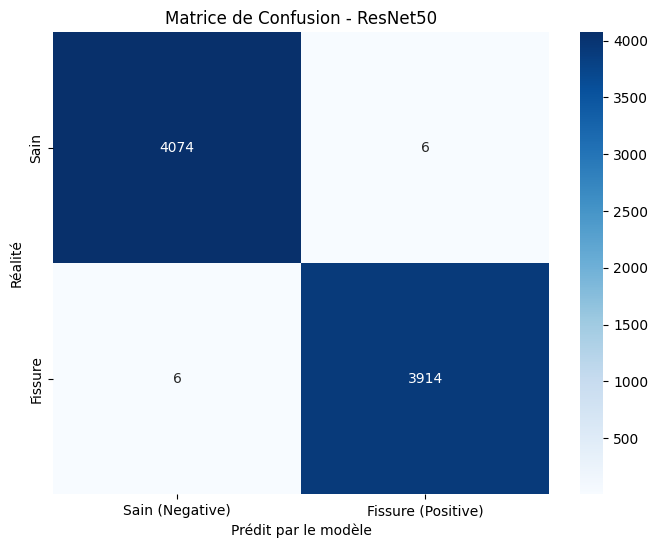

RAPPORT DE CLASSIFICATION DÉTAILLÉ :
              precision    recall  f1-score   support

        Sain       1.00      1.00      1.00      4080
     Fissure       1.00      1.00      1.00      3920

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [15]:


#  On prépare les prédictions sur tout le jeu de test
print("Calcul des prédictions finales ")

# On récupère les vraies étiquettes (y_true) et les images
y_true = []
y_pred = []

# On parcourt le jeu de validation
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    # On demande au modèle ResNet de prédire
    preds = model_resnet.predict(images, verbose=0)
    # Si > 0.5 c'est une fissure (1), sinon c'est sain (0)
    y_pred.extend(np.where(preds > 0.5, 1, 0).flatten())

#  Création de la Matrice de Confusion
cm = confusion_matrix(y_true, y_pred)

#  Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Sain (Negative)', 'Fissure (Positive)'], yticklabels=['Sain', 'Fissure'])
plt.xlabel('Prédit par le modèle')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - ResNet50')
plt.show()


print("RAPPORT DE CLASSIFICATION DÉTAILLÉ :")
print(classification_report(y_true, y_pred, target_names=['Sain', 'Fissure']))